In [4]:

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.tsa.api as smt

In [5]:
# аналогичным образом загружаем данные о пассажирах
ecg = pd.read_csv('calm_p.csv')

# неподходящий формат данных приводим к тому, с которым Pandas может работать

df = ecg.set_index('Time').sort_index()

### Скользящее среднее

In [6]:
df['MA_window_3'] = df['1'].rolling(window=3).mean()
df

,1,2,3,4,5,6,MA_window_3
Time,,,,,,,
10.000,1.313532,-0.367128,-0.293800,1.946667,1.873333,-0.330268,NaN
10.001,1.312748,-0.369088,-0.294584,1.947843,1.873333,-0.331836,NaN
10.002,1.312356,-0.370657,-0.294976,1.948627,1.872941,-0.332621,1.312879
10.003,1.311179,-0.372618,-0.294976,1.949804,1.872157,-0.333797,1.312094
10.004,1.310787,-0.374578,-0.295761,1.950980,1.872157,-0.334973,1.311441
...,...,...,...,...,...,...,...
59.995,1.357450,-0.084404,-0.099697,1.822745,1.838039,-0.091854,1.357058
59.996,1.357450,-0.083227,-0.098912,1.822353,1.838039,-0.091070,1.357319
59.997,1.357058,-0.082443,-0.097344,1.822353,1.837255,-0.089893,1.357319


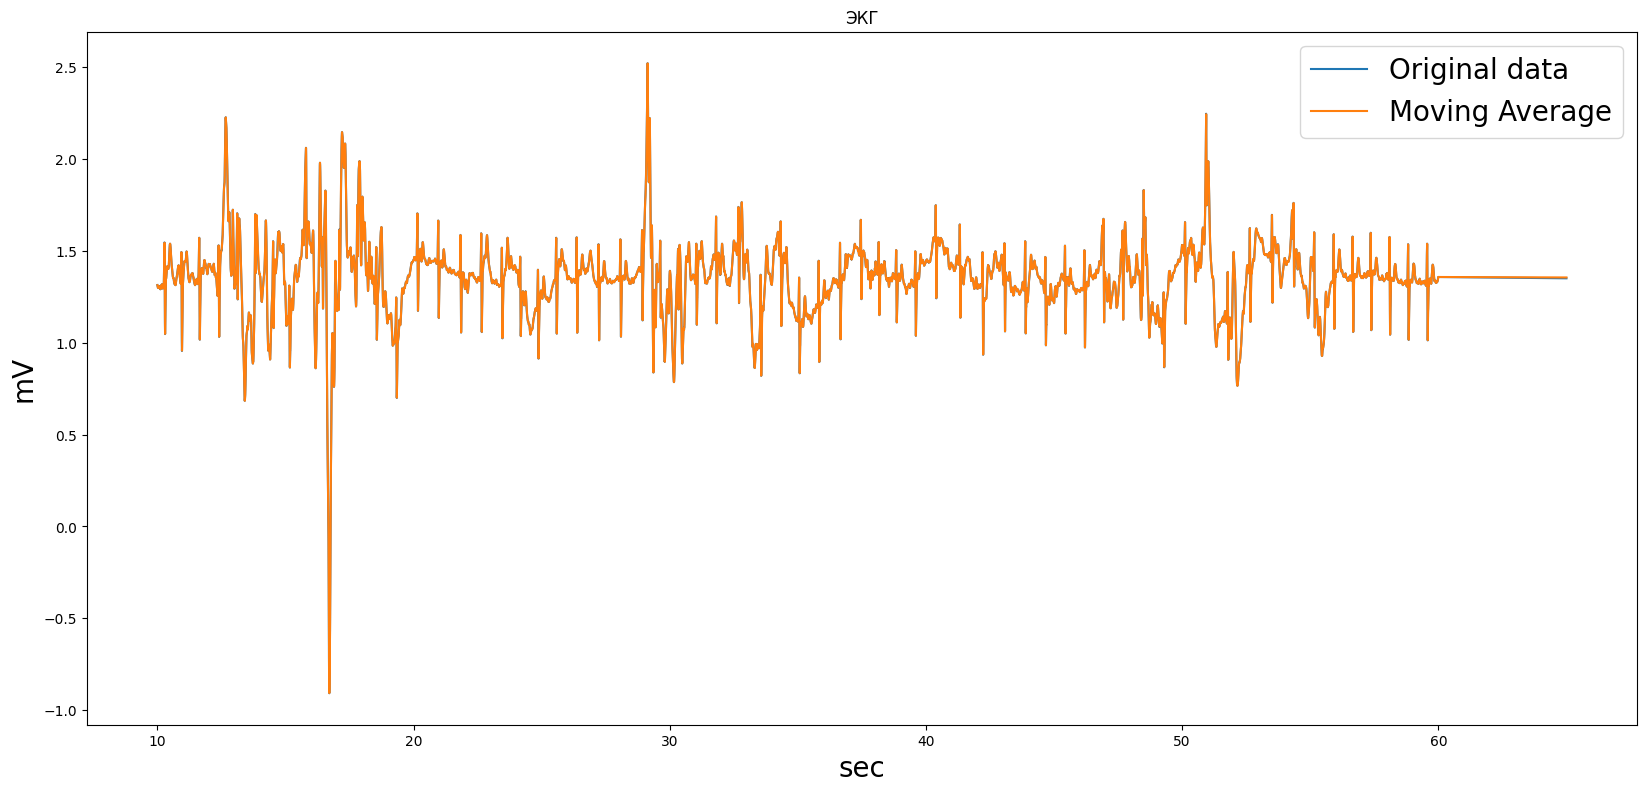

In [7]:
fig = plt.figure(figsize=(20, 9))
plt.plot(df['1'], label='Original data')
plt.plot(df['MA_window_3'], label='Moving Average')
plt.legend(fontsize="20")
plt.title('ЭКГ')
plt.ylabel('mV', fontsize="20")
plt.xlabel('sec', fontsize="20")
plt.show()

Можно поиграться с размерностью окна

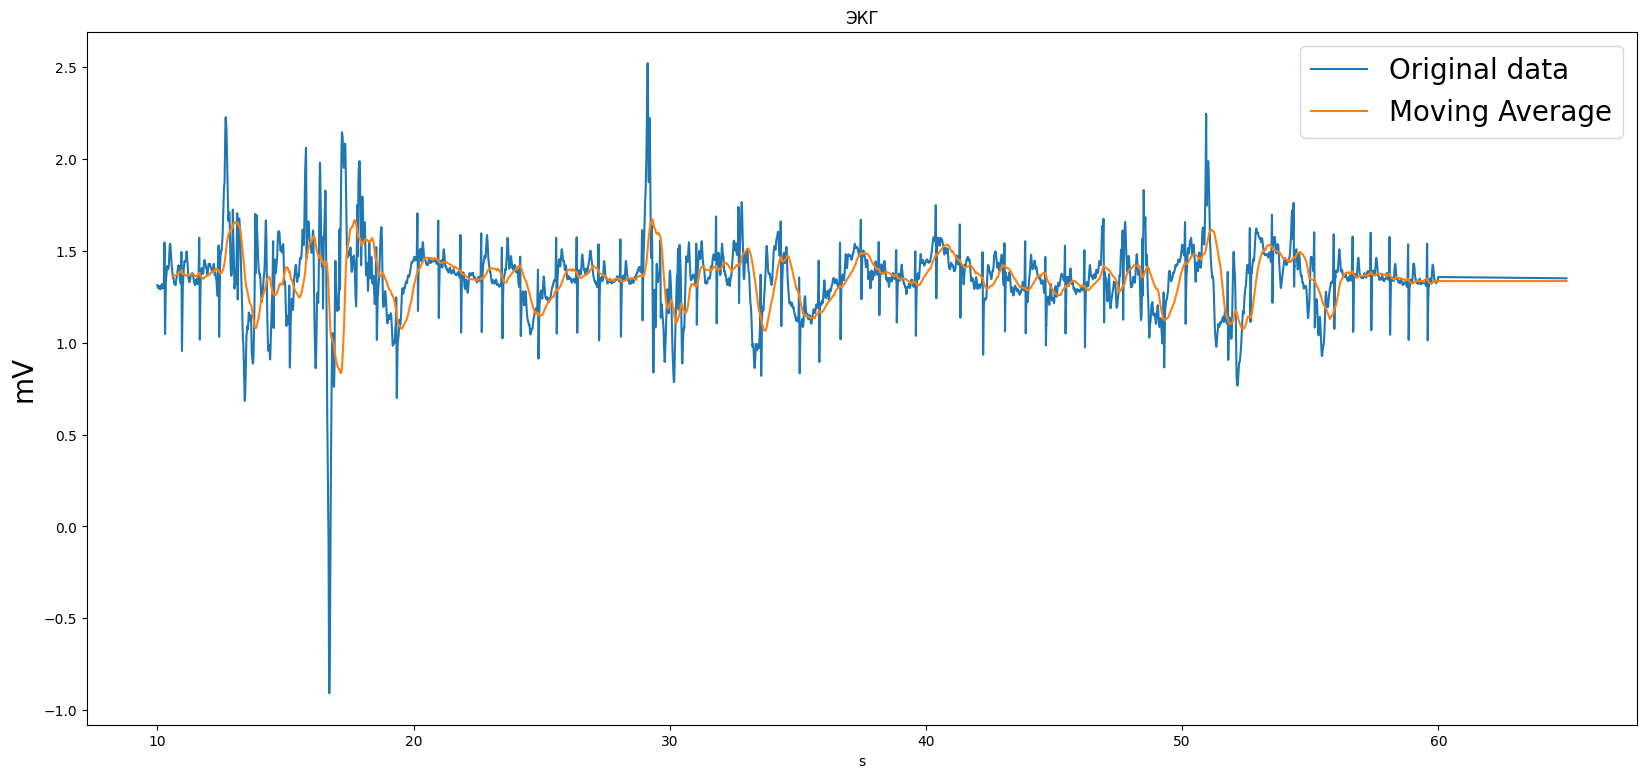

In [8]:
df['MA_window_6'] = df['1'].rolling(window=600).mean()
fig = plt.figure(figsize=(20, 9))
plt.plot(df['1'], label='Original data')
plt.plot(df['MA_window_6'], label='Moving Average')
plt.legend(fontsize="20")
plt.title('ЭКГ')
plt.ylabel('mV', fontsize="20")
plt.xlabel('s')
plt.show()


Давайте напишем функцию, которая поможет нам понять тенденцию и движения временного ряда. Мы хотим видеть на графике некоторую скользящую статистику, такую как:

M скользящее среднее: невзвешенное среднее предыдущих n данных (также называемое скользящим средним).

Полосы Боллинджера: верхняя полоса в k раз на n -периодное стандартное отклонение выше скользящей средней и нижняя полоса в k раз на стандартное отклонение N ниже.

In [9]:
'''
Отрисовка скользящего среднего по медиане для ts с 95% доверительным интервалом для стандартного отклонения.
:parameter
  :param ts: датасет
  :param window: кол-во семплов в окне - для скользящих средних
  :param plot_ma: bool - whether plot moving average
  :param plot_intervals: bool - whether plot upper and lower bounds
'''
def plot_ts(ts, plot_ma=True, plot_intervals=True, window=100,
            figsize=(15,5)):
    rolling_mean = ts.rolling(window=window).mean()
    rolling_std = ts.rolling(window=window).std()
    plt.figure(figsize=figsize)
    plt.title(ts.name)
    plt.plot(ts[window:], label='Реальные значения', color="black")
    if plot_ma:
        plt.plot(rolling_mean, 'g', label='MA'+str(window),
                 color="red")
    if plot_intervals:
        lower_bound = rolling_mean - (1.96 * rolling_std)
        upper_bound = rolling_mean + (1.96 * rolling_std)
    plt.fill_between(x=ts.index, y1=lower_bound, y2=upper_bound,
                     color='lightskyblue', alpha=0.4)
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

/tmp/ipykernel_8586/3736708662.py:15: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  plt.plot(ts[window:], label='Реальные значения', color="black")
/tmp/ipykernel_8586/3736708662.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g" (-> color=(0.0, 0.5, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(rolling_mean, 'g', label='MA'+str(window),


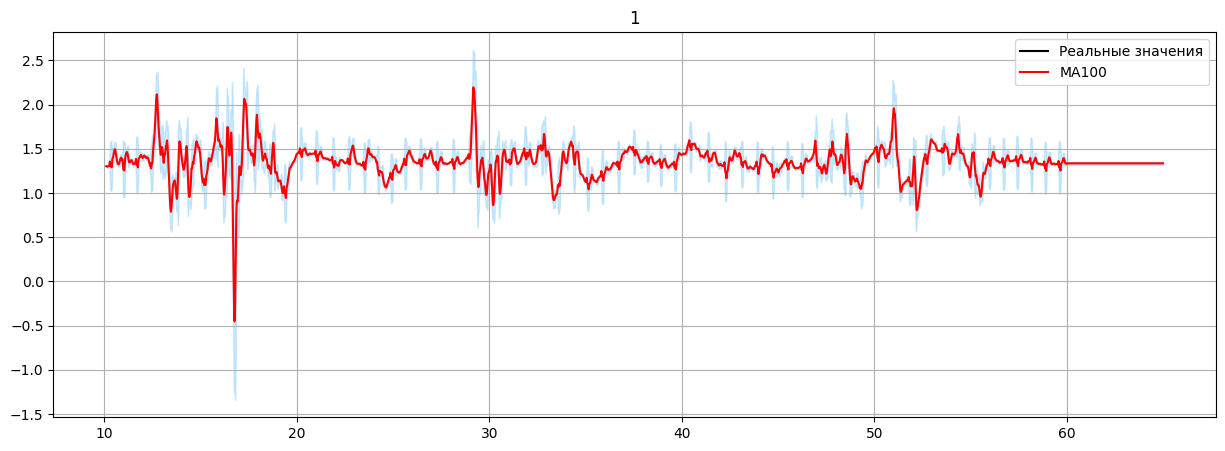

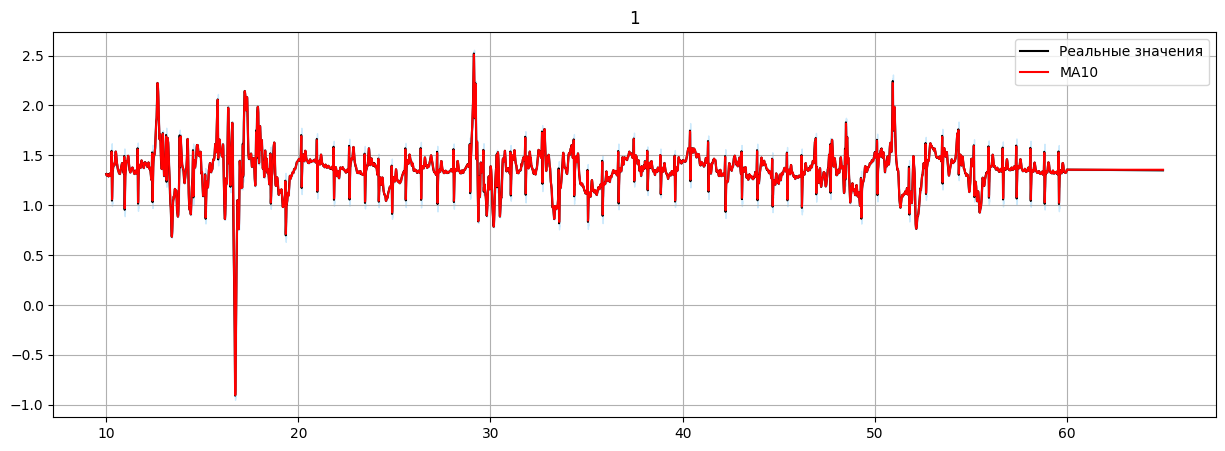

In [10]:
plot_ts(df["1"], window=100)
plot_ts(df["1"], window=10)

### ARMA

In [11]:
from statsmodels.tsa.arima.model import ARIMA

## Предсказание ряда на основе предыдущих значений

### ARIMA  

Модель авторегрессии скользящего среднего и систематический подход к её построению предназначена для анализа стационарных временных рядов на основе оценки линейной зависимости прогнозируемых значений от исторических.

Для использования модели временной ряд должен быть стационарным, т.е. его среднее и дисперсия должны быть постоянны.

Модель Бокса-Дженкинса предполагает, что временной ряд содержит три составляющие: авторегресионную, интегрированную и скользящее среднее, которые в модели обозначены $p$, $d$ и $q$ соответственно:

* Величина $p$ называется порядком авторегрессии. Она позволяет ответить на вопрос, будет ли очередной элемент ряда близок к значению $X$, если к нему были близки $p$ предыдущих значений.
* Величину $d$ называют порядком интегрирования. Она показывает, насколько элемент ряда близок по значению к $d$ предыдущим значениям, если разность между ними минимальна.

* Параметр $q$— порядок скользящего среднего. Позволяет установить погрешность модели как линейную комбинацию наблюдавшихся ранее значений ошибок.

Авторегрессия — это составляющая модели временного ряда, в которой его прогнозируемое значение может быть выражено в виде линейной комбинации исторических значений этого же ряда и случайной ошибки.

Обычно модель упоминается, как ARIMA$(p,d,q)$, где $p$, $d$ и $q$ — целые неотрицательные числа, характеризующие порядок для частей модели (соответственно авторегрессионной, интегрированной и скользящего среднего).

Для временного ряда $X(t)$ модель может быть записана в виде:

$$(\delta^dX_t)=\sum^p_{t=1}a_t(\delta^dX_{t-1}) + \epsilon_t + \sum^q_{j=1}b_j(\delta^d\epsilon_{t-j})$$

где

* $\delta^d$ — оператор разности порядка $d$ (последовательное взятие $d$ раз разностей первого порядка — сначала от самого ряда, затем от полученных разностей первого порядка, затем от второго порядка и т. д.);
* $a_t$— коэффициенты авторегрессионной части модели, $\epsilon_t$— значения ошибки (полагаются независимыми одинаково распределёнными случайными величинами из нормального распределения с нулевым средним);
* $b_j$ — коэффициенты скользящего среднего.

Модель Бокса-Дженкинса широко применяются при прогнозировании временных рядов. Основная задача при этом заключается в оценке параметров модели. Методология построения ARIMA-модели исследуемого временного ряда включает следующие основные этапы:

* построение пробной модели;
* оценивание параметров модели и проверка адекватности модели;
* использование модели для прогнозирования.

Чтобы построить модель ARMA, мы можем использовать функцию ARIMA (которая будет
объяснена в следующем разделе) в statsmodels.tsa.arima.model и указать
гиперпараметр — order(p, d, q). Когда d = 0, он работает как модель ARMA.

In [12]:
arma_model = ARIMA(df['1'], order=(5,0,3))
arma_model_fit = arma_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Usin

In [13]:
print(arma_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      1   No. Observations:                50000
Model:                 ARIMA(5, 0, 3)   Log Likelihood              232380.223
Date:                Thu, 14 May 2026   AIC                        -464740.446
Time:                        14:51:38   BIC                        -464652.248
Sample:                             0   HQIC                       -464712.818
                              - 50000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3528      0.004    303.878      0.000       1.344       1.362
ar.L1         -0.3986      0.013    -31.782      0.000      -0.423      -0.374
ar.L2          1.3965      0.007    199.295      0.0

In [14]:
X = df['1'].values
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
arma_predictions = list()
# walk-forward validation
for t in range(len(test)):
    model = ARIMA(history, order=(5,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    arma_predictions.append(yhat)
    obs = test[t]
    history.append(obs)

KeyboardInterrupt: 

In [15]:
print(len(train))
print(len(test))
print(len(arma_predictions))

33000
17000
59


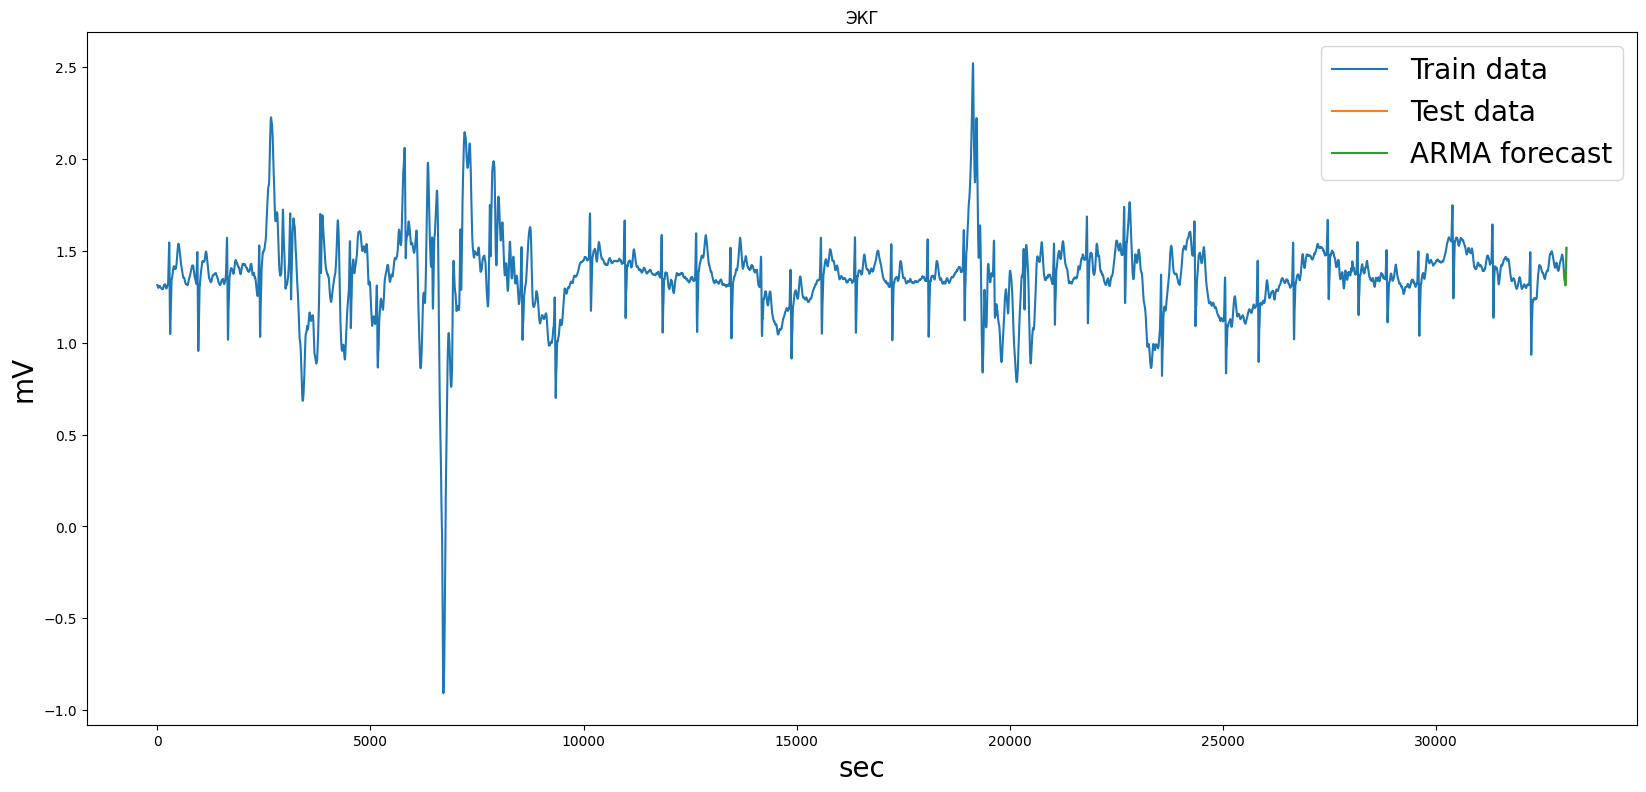

In [16]:
fig = plt.figure(figsize=(20, 9))
dur = len(arma_predictions)

plt.plot([i for i in range(0, size)], train, label='Train data')
plt.plot([i for i in range(size - 1, size - 1 + dur)], test[:dur], label='Test data')
plt.plot([i for i in range(size - 1, size - 1 + dur)], arma_predictions, label='ARMA forecast')
plt.legend(fontsize="20")
plt.title('ЭКГ')
plt.ylabel('mV', fontsize="20")
plt.xlabel('sec', fontsize="20")
plt.show()

In [19]:
# аналогичным образом загружаем данные о пассажирах
passengers = pd.read_csv('passengers.csv')
# неподходящий формат данных приводим к тому, с которым Pandas может работать
passengers['Month'] = pd.to_datetime(passengers['Month'])
# также устанавливаем индекс и сортируем
pdf = passengers.set_index('Month').sort_index()

In [20]:
passengers

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [21]:
p_arma_model = ARIMA(pdf['Passengers'], order=(5,0,3))
p_arma_model_fit = p_arma_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [22]:
from IPython.display import clear_output
%matplotlib inline

def live_plot(data_dict, figsize=(7,5), title=''):
    clear_output(wait=True)
    plt.figure(figsize=figsize)
    for label,data in data_dict.items():
        plt.plot(data, label=label)
    plt.title(title)
    plt.grid(True)
    plt.xlabel('epoch')
    plt.legend(loc='center left')
    plt.show()

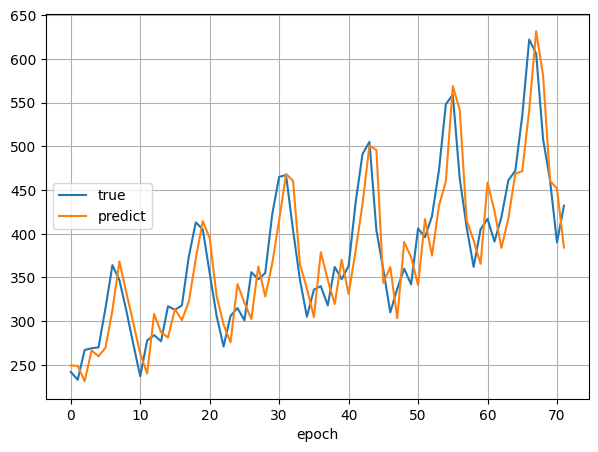

In [23]:
series = pdf["Passengers"]
#series = df['1']

size = int(series.shape[0] * 0.5)
train, test = series[:size], series[size:len(series)]
history = [x for x in train.values]
predictions = []

val = {"true":[], "predict":[]}
for t in test.values:
    model = ARIMA(history, order=(5,1,0)).fit()
    output = model.forecast()
    yhat = output[0]
    predictions.append(yhat)
    val["predict"].append(yhat)
    val["true"].append(t)
    history.append(t)
    live_plot(val)

In [24]:
X = pdf['Passengers'].values
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
arma_predictions = list()
# walk-forward validation
for t in range(len(test)):
    model = ARIMA(history, order=(5,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    arma_predictions.append(yhat)
    obs = test[t]
    history.append(obs)

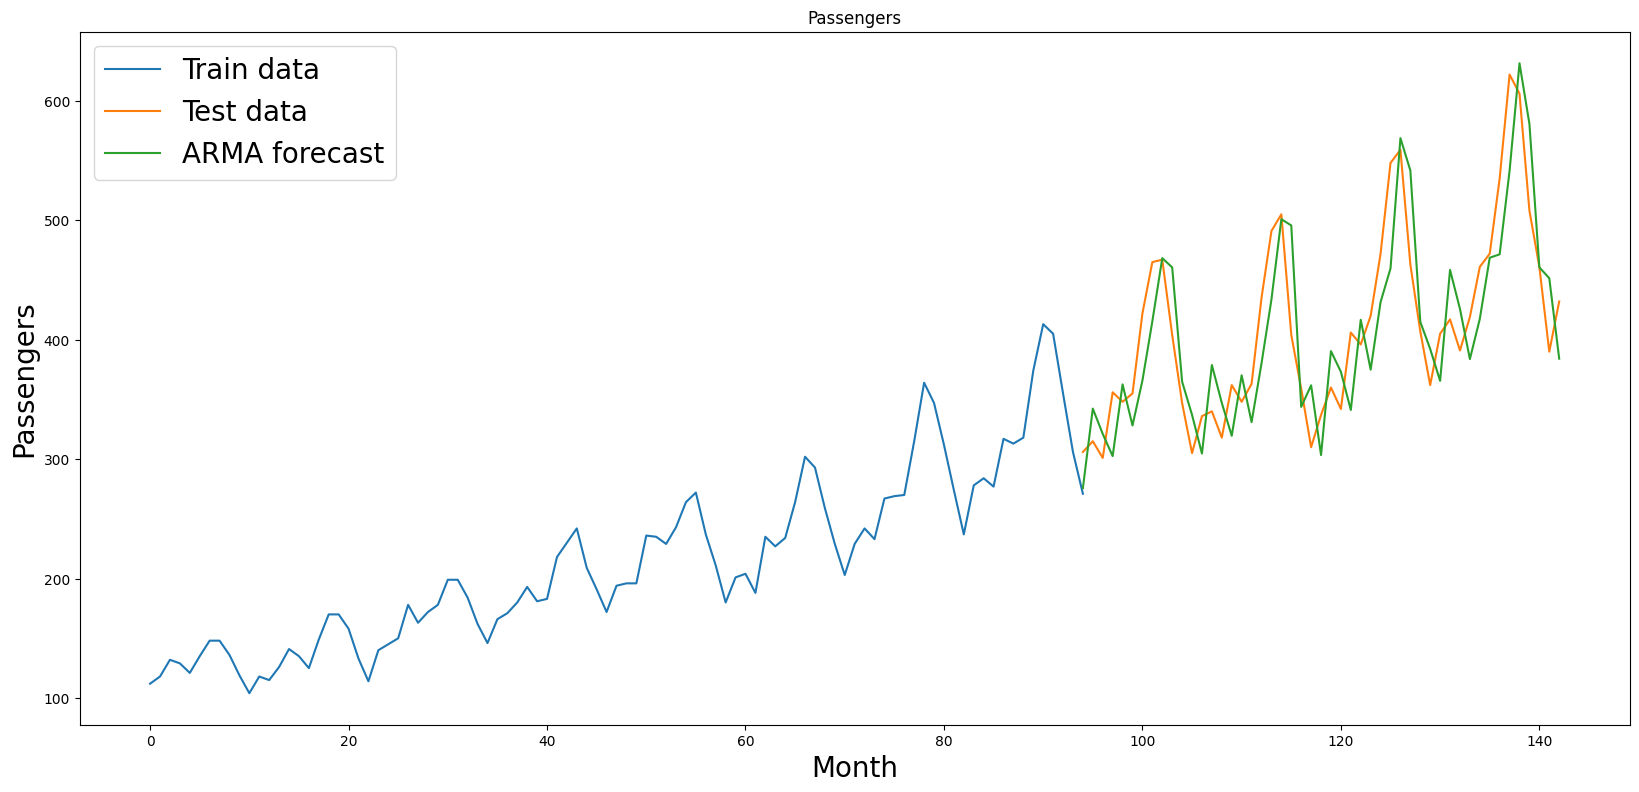

In [25]:
fig = plt.figure(figsize=(20, 9))
dur = len(arma_predictions)

plt.plot([i for i in range(0, size)], train, label='Train data')
plt.plot([i for i in range(size - 1, size - 1 + dur)], test[:dur], label='Test data')
plt.plot([i for i in range(size - 1, size - 1 + dur)], arma_predictions, label='ARMA forecast')
plt.legend(fontsize="20")
plt.title('Passengers')
plt.ylabel('Passengers', fontsize="20")
plt.xlabel('Month', fontsize="20")
plt.show()

### ARIMA

In [26]:
arima_model = ARIMA(pdf['Passengers'], order=(10,2,10))
arima_model_fit = arima_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. 

In [27]:
print(arima_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:               ARIMA(10, 2, 10)   Log Likelihood                -555.051
Date:                Thu, 14 May 2026   AIC                           1152.101
Time:                        15:03:34   BIC                           1214.174
Sample:                    01-01-1949   HQIC                          1177.325
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0737      0.062      1.196      0.232      -0.047       0.195
ar.L2         -1.0001      0.082    -12.217      0.000      -1.160      -0.840
ar.L3          0.0153      0.094      0.163      0.8

Полезным может быть получение линейного графика остаточных ошибок, что позволяет предположить, что некоторая информация о тенденциях все еще может быть не учтена моделью.

<Axes: xlabel='Month'>

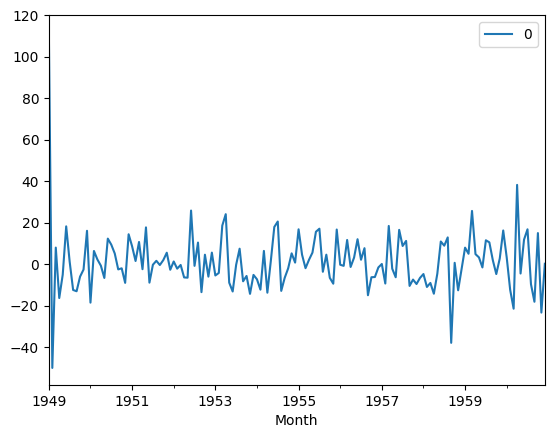

In [28]:
arima_residuals = pd.DataFrame(arima_model_fit.resid)
arima_residuals.plot()

Осуществляем предсказание

In [29]:
# forecast предсказывает только следующее значение
output = arima_model_fit.forecast()

In [30]:
X = pdf['Passengers'].values
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
arima_predictions = list()
# walk-forward validation
for t in range(len(test)):
    arima_model = ARIMA(history, order=(10,2,5))
    arima_model_fit = arima_model.fit()
    output = arima_model_fit.forecast()
    yhat = output[0]
    arima_predictions.append(yhat)
    obs = test[t]
    history.append(obs)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: Conver

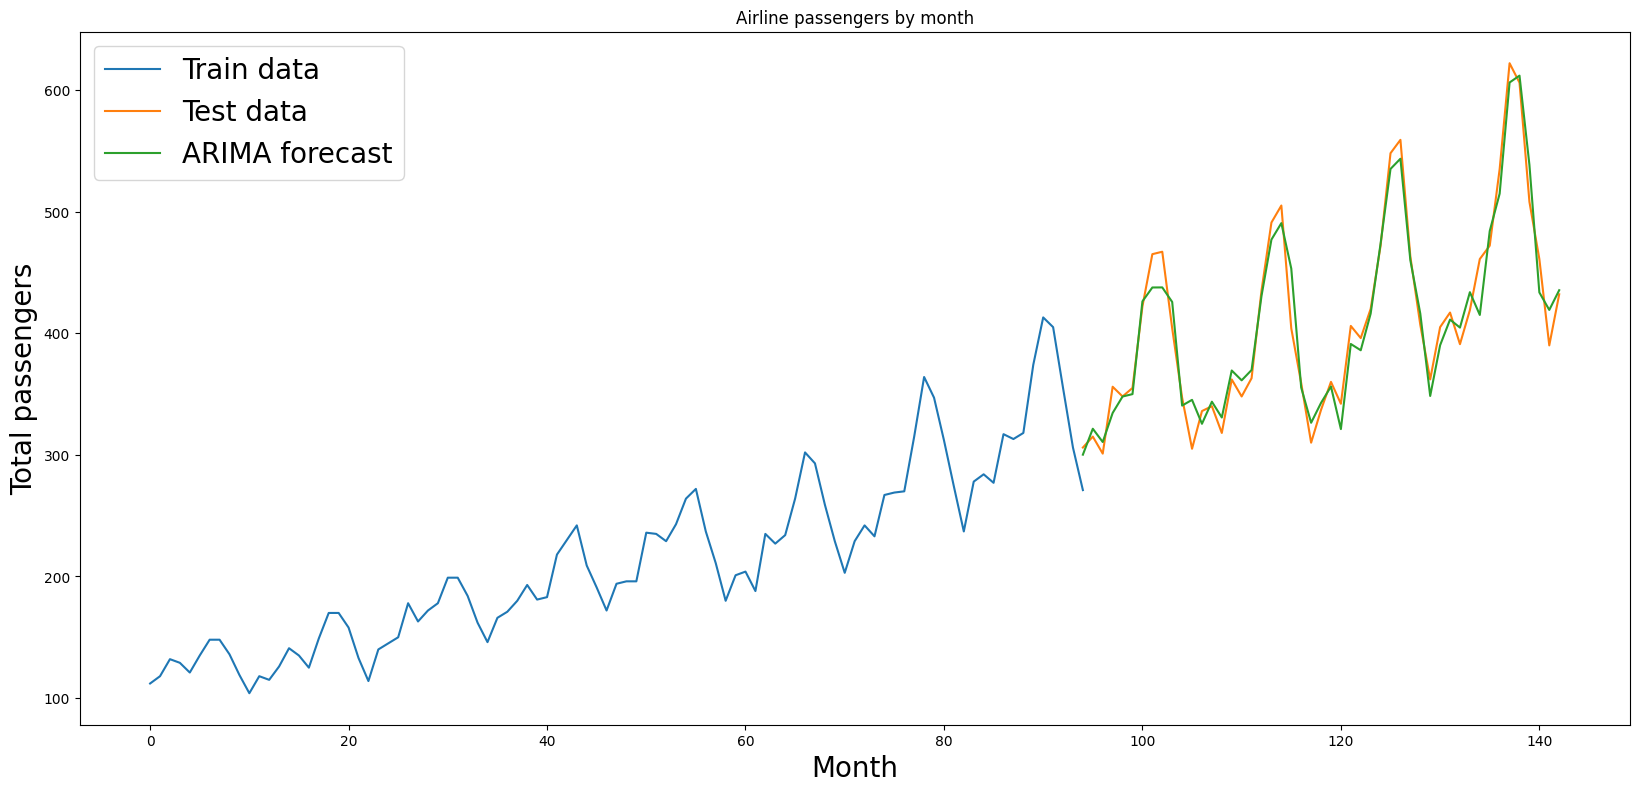

In [31]:
fig = plt.figure(figsize=(20, 9))
plt.plot([i for i in range(0, size)], train, label='Train data')
plt.plot([i for i in range(size - 1, len(X) - 1)], test, label='Test data')
plt.plot([i for i in range(size - 1, len(X) - 1)], arima_predictions, label='ARIMA forecast')
plt.legend(fontsize="20")
plt.title('Airline passengers by month')
plt.ylabel('Total passengers', fontsize="20")
plt.xlabel('Month', fontsize="20")
plt.show()

Сравним значения ARMA и ARIMA

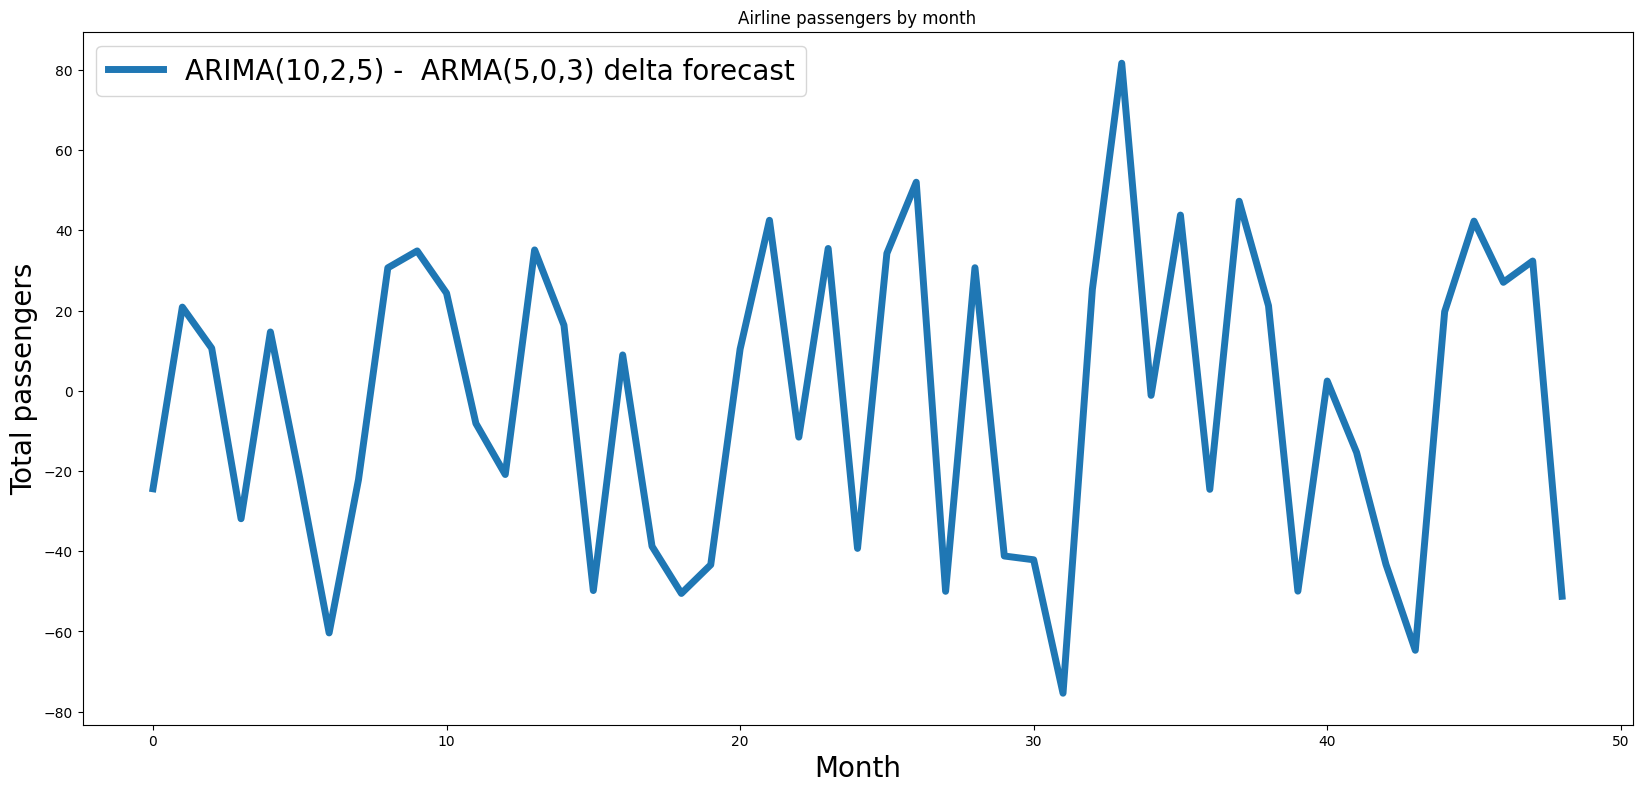

In [32]:
fig = plt.figure(figsize=(20, 9))

delta = []

for i in range(len(arima_predictions)):
    delta.append(arma_predictions[i] - arima_predictions[i])

plt.plot(delta, label='ARIMA(10,2,5) -  ARMA(5,0,3) delta forecast', linewidth=5)
plt.legend(fontsize="20")
plt.title('Airline passengers by month')
plt.ylabel('Total passengers', fontsize="20")
plt.xlabel('Month', fontsize="20")
plt.show()

### Работа с пропусками данных

#### **Задание №1:**


Заполнените пропущенные значения:
* средним и медианой​
* предыдущим и последующим значениями​
* скользящим средним и медианой​

/tmp/ipykernel_8586/269832421.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  o_df["Passengers"][50:55] = np.nan


<Axes: xlabel='Month'>

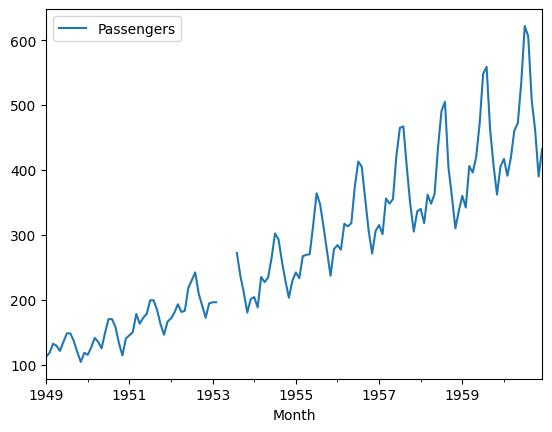

In [33]:
o_df = pdf.copy()

o_df["Passengers"][50:55] = np.nan

o_df.plot()

<Axes: title={'center': 'среднее из предыдущего и последующего'}, xlabel='Month'>

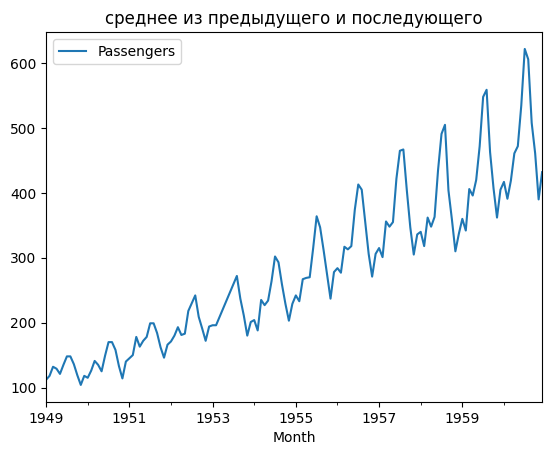

In [34]:
# Ваш код
o_df['Passengers'] = o_df['Passengers'].interpolate(method='linear')

o_df.plot(title="среднее из предыдущего и последующего")

Заполнение предыдущим и последующим значениями​

<Axes: title={'center': 'Последующее значение'}, xlabel='Month'>

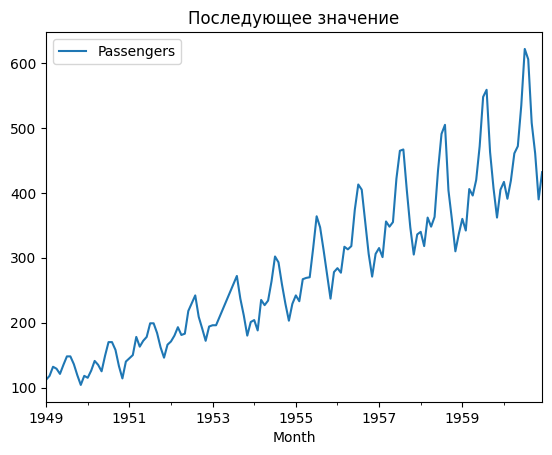

In [35]:
# Ваш код
o_df['Passengers'] = o_df['Passengers'].bfill()

o_df.plot(title='Последующее значение')

Заполнение скользящим средним и медианой​

<Axes: title={'center': 'медиана'}, xlabel='Month'>

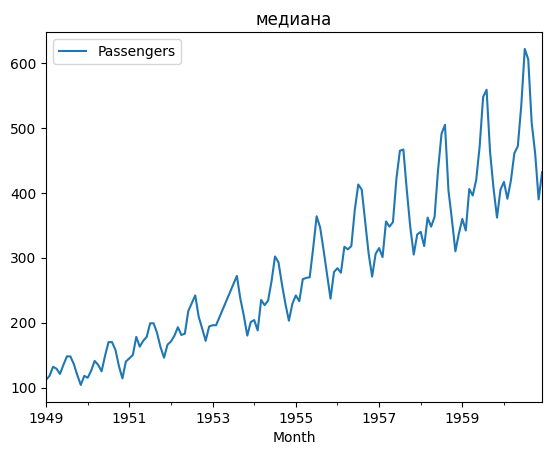

In [36]:
# ваш код
median_val = o_df['Passengers'].median()
o_df['Passengers'] = o_df['Passengers'].fillna(median_val)

o_df.plot(title='медиана')

<Axes: title={'center': 'среднее'}, xlabel='Month'>

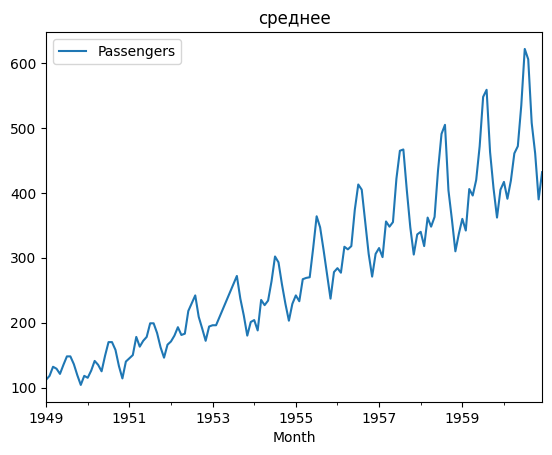

In [37]:
# Ваш код
mean_val = o_df['Passengers'].mean()
o_df['Passengers'] = o_df['Passengers'].fillna(mean_val)

o_df.plot(title='среднее')

Интерполяция

/tmp/ipykernel_8586/2057132815.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  o_df["Passengers"][50:55] = np.nan


<Axes: title={'center': 'zero'}, xlabel='Month'>

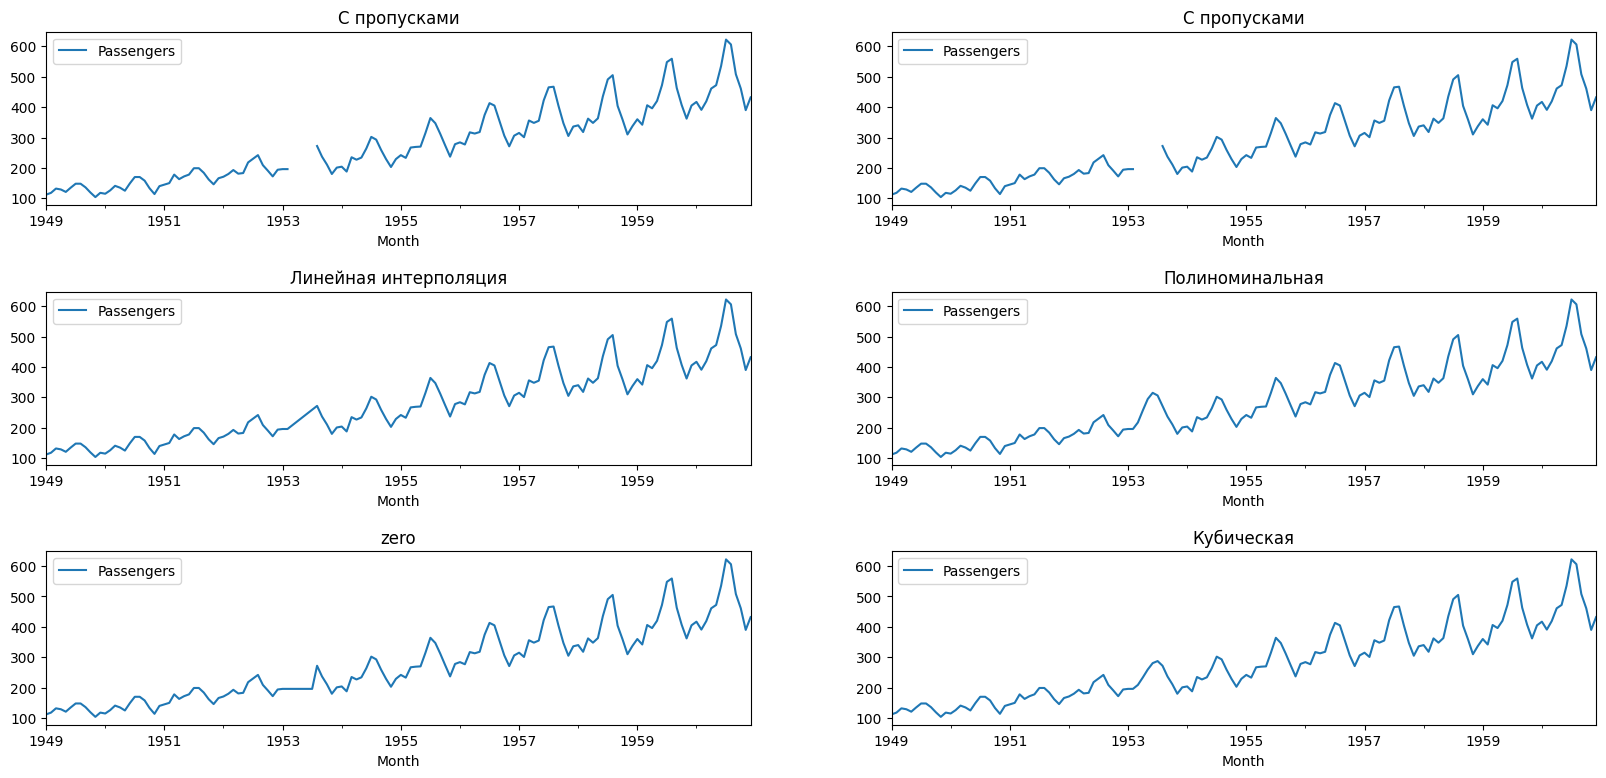

In [38]:
o_df["Passengers"][50:55] = np.nan

lin_df = o_df.interpolate(method="linear")

cub_df = o_df.interpolate(method="cubic")

pol_df = o_df.interpolate(method="polynomial", order=5)

zero_df = o_df.interpolate(method="zero")


fig = plt.figure(figsize=(20, 9))
layout = (3, 2)
plt.subplots_adjust(wspace=0.2, hspace=0.5)

original_ax = plt.subplot2grid(layout, (0, 0))
lin_ax = plt.subplot2grid(layout, (1, 0))
cub_ax = plt.subplot2grid(layout, (2, 1))

pol_ax = plt.subplot2grid(layout, (1, 1))
zero_ax = plt.subplot2grid(layout, (2, 0))

o_df.plot(title="С пропусками", ax = original_ax)
o_df.plot(title="С пропусками", ax = plt.subplot2grid(layout, (0, 1)))
lin_df.plot(title="Линейная интерполяция", ax = lin_ax)
cub_df.plot(title="Кубическая", ax = cub_ax)
pol_df.plot(title="Полиноминальная", ax = pol_ax)
zero_df.plot(title="zero", ax=zero_ax)


### Работа с выбросами

In [39]:
import seaborn as sns

<Axes: >

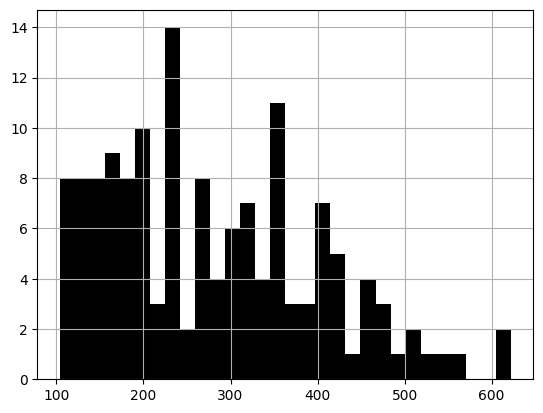

In [40]:
pdf["Passengers"].hist(bins=30, color="black")

<Axes: >

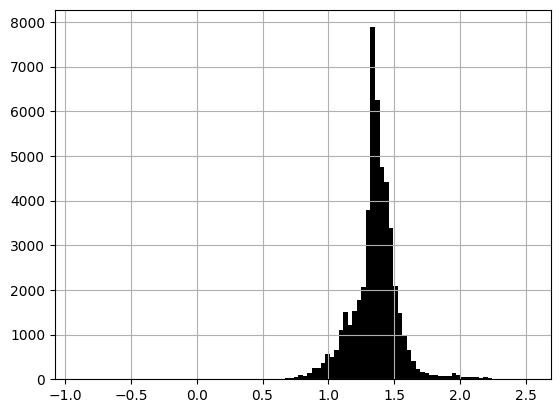

In [41]:
ecg["1"].hist(bins=100, color="black",)

Text(0.5, 1.0, 'Пассажиры')

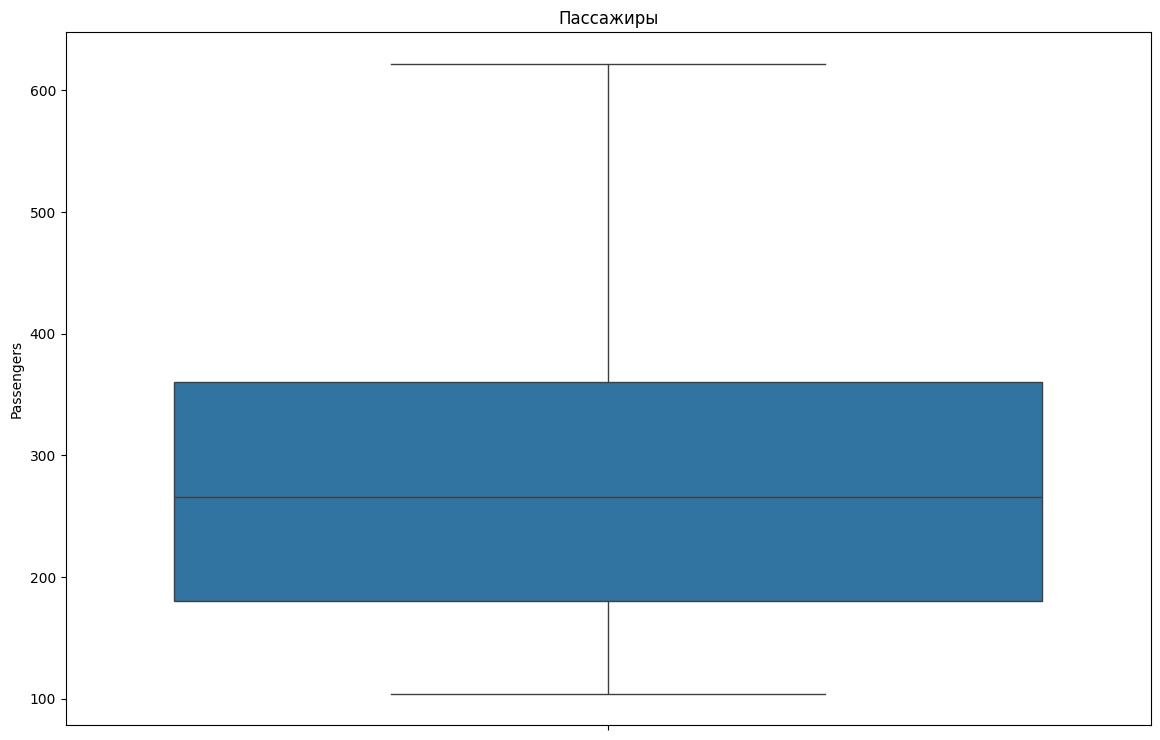

In [42]:
fig = plt.figure(figsize=(14, 9))

sns.boxplot(pdf.Passengers).set_title('Пассажиры')

Text(0.5, 1.0, 'ЭКГ')

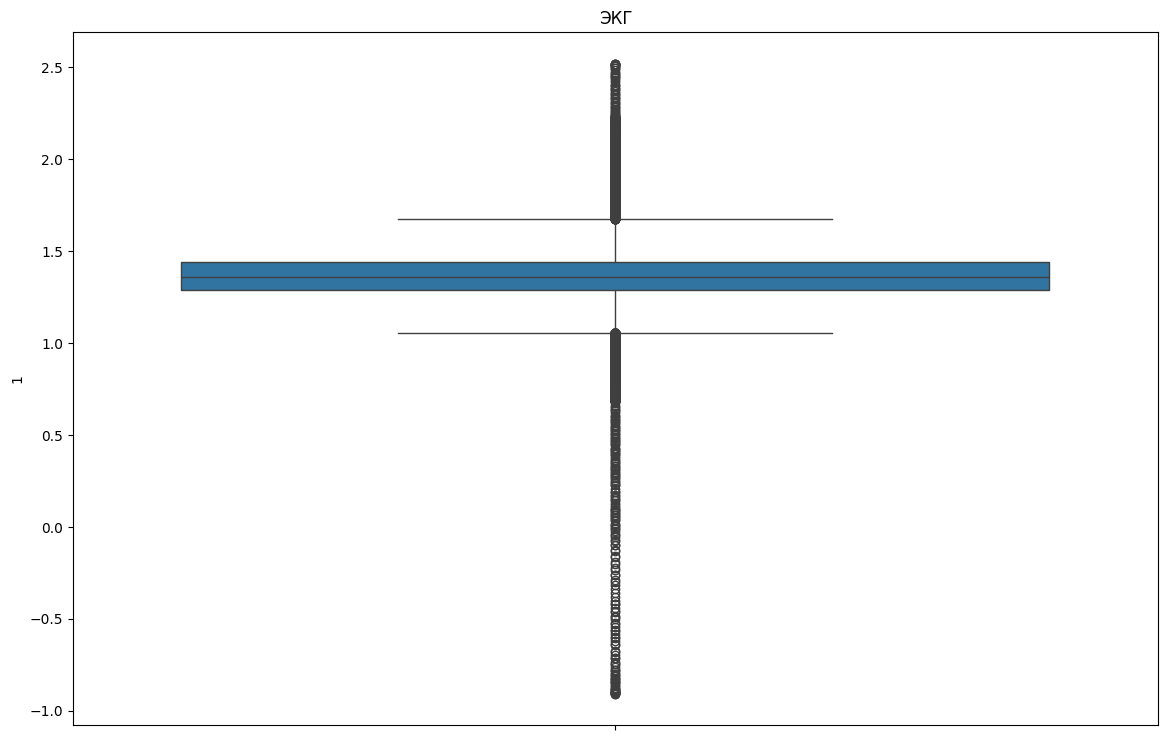

In [43]:
fig = plt.figure(figsize=(14, 9))
ax = sns.boxplot(ecg["1"])
ax.set_title('ЭКГ')

Давайте напишем функцию для автоматического обнаружения выбросов во временном ряду с использованием алгоритма кластеризации из библиотеки scikit-learn: машина векторов поддержки одного класса, она изучает границы распределения (называемые « support ») и, следовательно, может классифицировать любые точки, лежащие за пределами границы, как выбросы.

In [44]:
from sklearn import preprocessing, svm

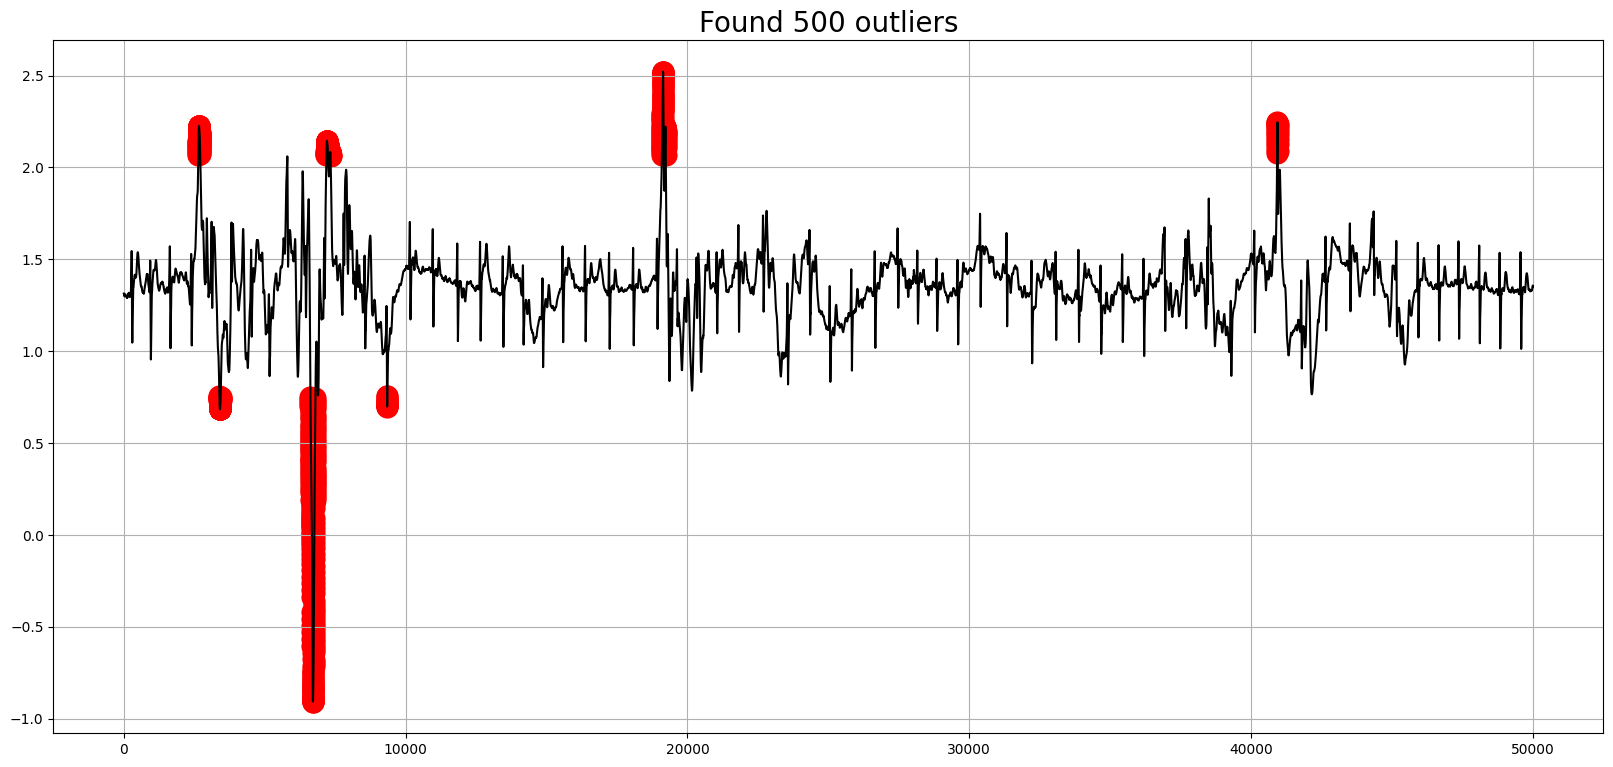

In [45]:
scaler = preprocessing.StandardScaler()
perc = 0.01

local_df = ecg["1"]

ts_scaled = scaler.fit_transform(local_df.values.reshape(-1,1))
model = svm.OneClassSVM(nu=perc, kernel="rbf", gamma=0.01)
model.fit(ts_scaled)
## dtf output
dtf_outliers =local_df.to_frame(name="ts")
dtf_outliers["index"] = range(len(local_df))
dtf_outliers["outlier"] = model.predict(ts_scaled)
dtf_outliers["outlier"] = dtf_outliers["outlier"].apply(lambda
                                                            x: 1 if x==-1 else 0)
## plot
fig, ax = plt.subplots(figsize=(20, 9))
ax.plot(dtf_outliers["index"], dtf_outliers["ts"],
        color="black")
ax.scatter(x=dtf_outliers[dtf_outliers["outlier"]==1]["index"],
           y=dtf_outliers[dtf_outliers["outlier"]==1]['ts'],
           color='red', linewidths=10)
plt.title(f"Found {sum(dtf_outliers['outlier']==1)} outliers", fontdict={'fontsize': 20})
ax.grid(True)
plt.show()

Но что нам делать с выбросами после обнаружения? Здесь нет оптимальной стратегии: прогнозировать временные ряды проще без точек данных, которые значительно отличаются от других наблюдений, но удаление этих точек может глубоко изменить распределение данных. Если вы решили исключить выбросы, наиболее удобный способ их удаления - интерполяция.

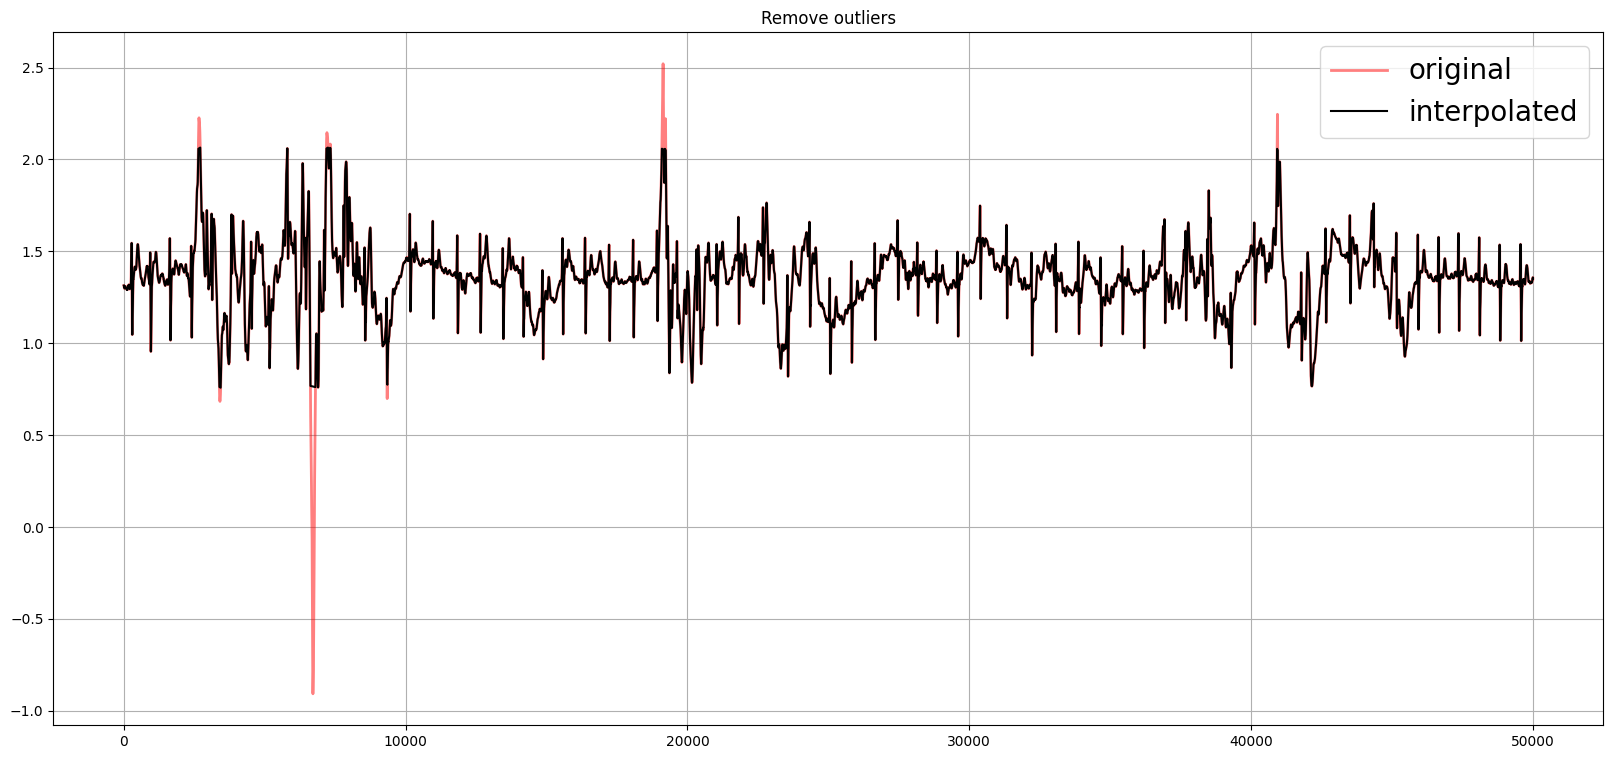

In [46]:
outliers_idx = dtf_outliers[dtf_outliers["outlier"]==1].index

ts_clean = local_df.copy()
ts_clean.loc[outliers_idx] = np.nan
ts_clean = ts_clean.interpolate(method="linear")
ax = local_df.plot(figsize=(20, 9), color="red", alpha=0.5,
             title="Remove outliers", label="original", legend=True, linewidth=2)
ts_clean.plot(ax=ax, grid=True, color="black",
              label="interpolated", legend=True)
plt.legend(fontsize="20")
plt.show()

# Задание №2: Анализ нестационарного ряда и прогнозирование с ARIMA

## Описание
У вас есть временной ряд продаж онлайн-магазина за 200 дней. Ряд нестационарный (имеет тренд и случайный шум).

**Ваша задача:**
* Загрузить и визуализировать ряд
* Проверить стационарность с помощью ADF-теста
* Применить дифференцирование и убедиться, что ряд стал стационарным
* Выбрать оптимальные параметры ARIMA(p,d,q)
* Сделать walk-forward прогноз на тестовом наборе
* Оценить качество прогноза (MAE, RMSE)


In [47]:
import numpy as np
import pandas as pd
np.random.seed(42)

# Генерируем нестационарный ряд
n = 200
trend = np.linspace(50, 250, n)  # Линейный тренд от 50 к 250
noise = np.random.normal(0, 15, n)  # Шум
random_walk = np.cumsum(np.random.normal(0, 5, n))  # Random walk

sales = trend + random_walk + noise

df = pd.DataFrame({'day': np.arange(1, n+1),'sales': sales})
df.set_index('day', inplace=True)
df.head(10)

,sales
day,
1,59.239649
2,53.523920
3,71.733494
4,91.137649
5,58.896579
6,55.212725
7,85.993173
8,77.390457
9,62.417084


2: Визуализация ряда

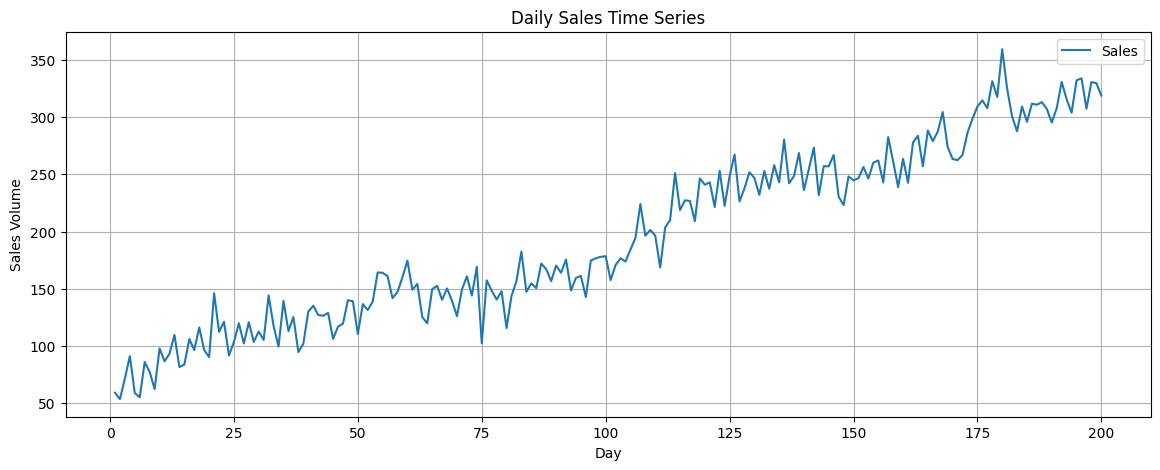

In [48]:
# Постройте график исходного временного ряда
# Используйте figsize=(14, 5), добавьте label, title, xlabel, ylabel
# Ваш код
import matplotlib.pyplot as plt

# Постройте график исходного временного ряда
plt.figure(figsize=(14, 5))
plt.plot(df['sales'], label='Sales')
plt.title('Daily Sales Time Series')
plt.xlabel('Day')
plt.ylabel('Sales Volume')
plt.legend()
plt.grid(True)
plt.show()

3: Проверка стационарности (ADF-тест)

**Тест Дики-Фуллера:**
- H0 (нулевая гипотеза): ряд имеет единичный корень (нестационарен)
- Если p-value < 0.05, мы отклоняем H0 → ряд стационарен
- Если p-value > 0.05, ряд нестационарен

In [49]:
# Ваш код
from statsmodels.tsa.stattools import adfuller

def check_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

    if dfoutput['p-value'] < 0.05:
        print("Ряд стационарен (отвергаем H0)")
    else:
        print("Ряд нестационарен (не отвергаем H0)")

# Ваш код
check_stationarity(df['sales'])

Results of Dickey-Fuller Test:
Test Statistic                  -0.592454
p-value                          0.872678
#Lags Used                       5.000000
Number of Observations Used    194.000000
Critical Value (1%)             -3.464515
Critical Value (5%)             -2.876556
Critical Value (10%)            -2.574775
dtype: float64
Ряд нестационарен (не отвергаем H0)


4: Дифференцирование

Возьмём первую разность: Δy_t = y_t - y_(t-1)

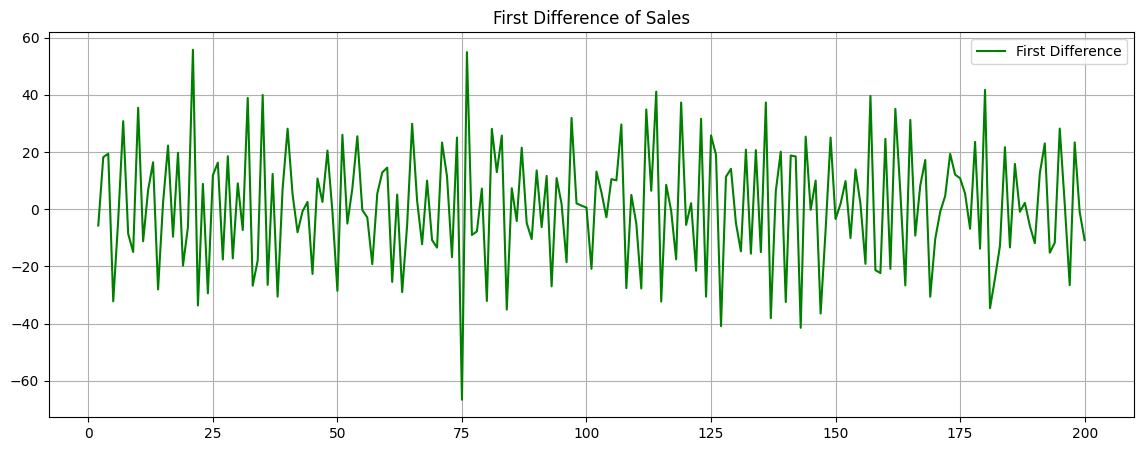

In [50]:
#  Применить первое дифференцирование (d=1)
# Используйте df['sales'].diff() для получения разностей
# Ваш код
df['sales_diff'] = df['sales'].diff()

df_diff = df.dropna(subset=['sales_diff'])

# Визуализация разностей (опционально, но полезно)
plt.figure(figsize=(14, 5))
plt.plot(df_diff['sales_diff'], label='First Difference', color='green')
plt.title('First Difference of Sales')
plt.legend()
plt.grid(True)
plt.show()

5: Проверка стационарности разности

In [51]:
# Используйте функцию check_stationarity()
# Ваш код
check_stationarity(df_diff['sales_diff'])

Results of Dickey-Fuller Test:
Test Statistic                -1.024398e+01
p-value                        4.669568e-18
#Lags Used                     4.000000e+00
Number of Observations Used    1.940000e+02
Critical Value (1%)           -3.464515e+00
Critical Value (5%)           -2.876556e+00
Critical Value (10%)          -2.574775e+00
dtype: float64
Ряд стационарен (отвергаем H0)


6: Выбор параметров ARIMA

Поскольку мы применили d=1, нам нужно выбрать p и q.
Совет: для т.ч. ряда часто подходят небольшие значения, например p=1-5, q=0-3

In [52]:
# Вариант 1 : начните с ARIMA(1,1,1)
# Вариант 2 : переберите несколько вариантов и выберите по AIC
# Выбирайте как душе угодно)

# Жду ваш код
import warnings
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

best_aic = np.inf
best_order = None
best_model = None

# Перебор небольших значений p и q, так как d=1 мы уже определили
for p in range(0, 6):
    for q in range(0, 4):
        try:
            model = ARIMA(df['sales'], order=(p, 1, q))
            model_fit = model.fit()
            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_order = (p, 1, q)
                best_model = model_fit
        except:
            continue

print(f"Best ARIMA Order: {best_order}")
print(f"Best AIC: {best_aic}")

Best ARIMA Order: (2, 1, 3)
Best AIC: 1702.2458691077834


7: Walk-Forward Validation и прогнозирование

In [53]:
# Ваш код
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Разделим данные на train и test
train_size = int(len(df) * 0.8)
train, test = df['sales'][:train_size], df['sales'][train_size:]

history = [x for x in train]
predictions = list()

# Walk-Forward Validation
for t in range(len(test)):
    # Обучаем модель на истории
    # Примечание: для скорости можно использовать best_order, найденный ранее
    model = ARIMA(history, order=best_order if best_order else (1,1,1))
    model_fit = model.fit()

    # Делаем прогноз на 1 шаг вперед
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)

    # Добавляем реальное значение в историю для следующего шага
    obs = test.iloc[t]
    history.append(obs)


8: Визуализация + метрики

MAE: 16.12
RMSE: 18.79


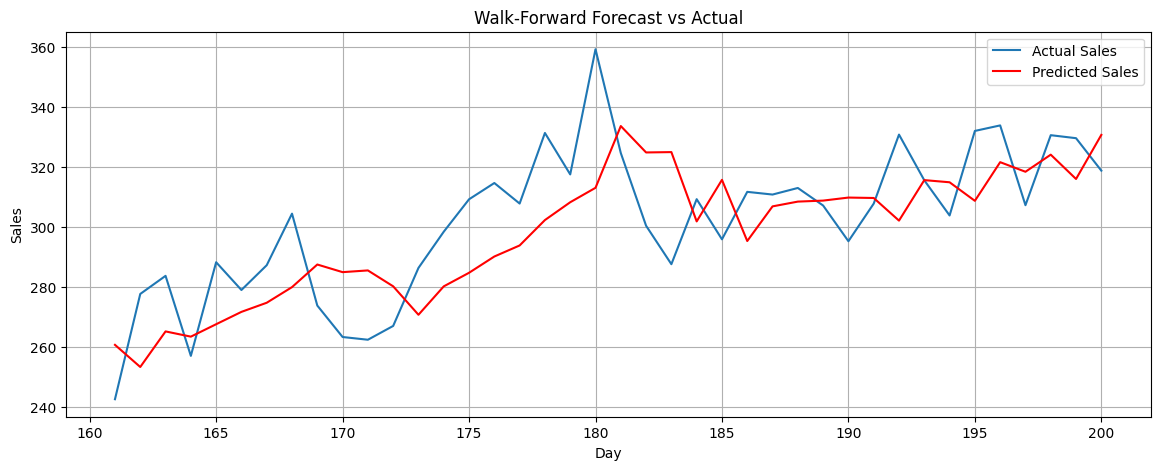

In [54]:
# Ваш код
# Расчет метрик
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')

# Визуализация
plt.figure(figsize=(14, 5))
plt.plot(test.index, test.values, label='Actual Sales')
plt.plot(test.index, predictions, label='Predicted Sales', color='red')
plt.title('Walk-Forward Forecast vs Actual')
plt.xlabel('Day')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()